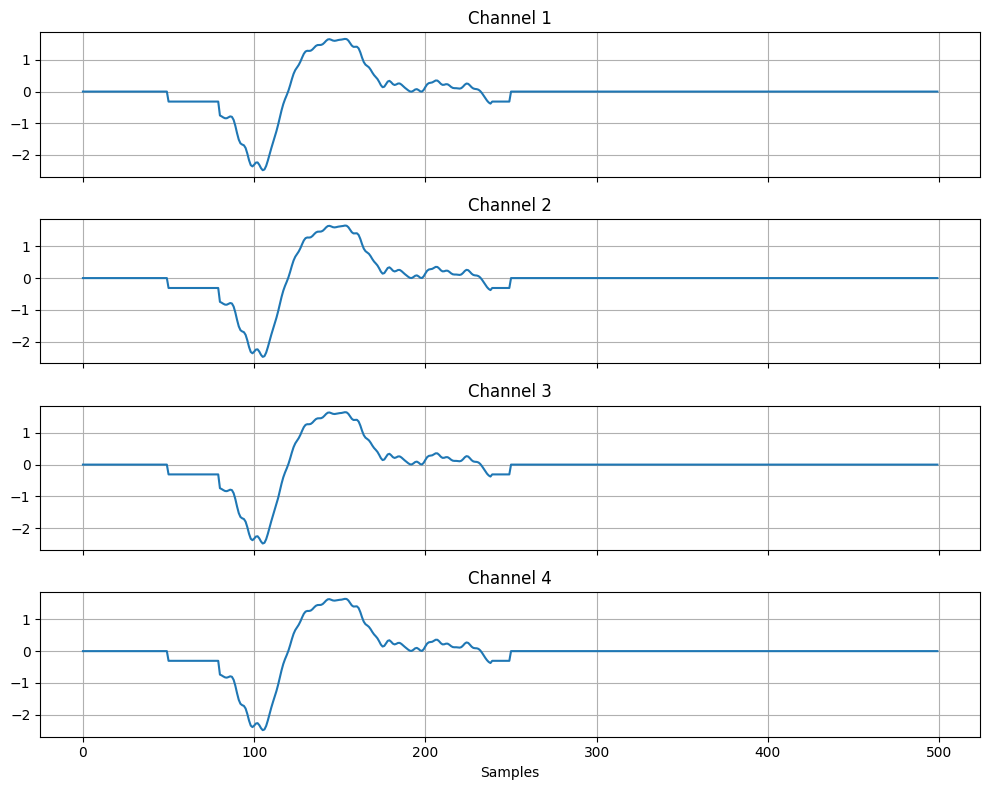

In [1]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from DeepMathedFilterModel import DeepMatchedDetector

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

detector_model = DeepMatchedDetector()
detector_model.load_state_dict(torch.load("./ERPDetectors/RandomERPDetector_7.pth", map_location=device))

templatesFile = 'channels_templates.mat'
with h5py.File(templatesFile, 'r') as f:
    templates = f['templates'][:]

padded_templates = np.pad(
    templates,
    ((50, 250), (0, 0)),  # (rows before/after, cols before/after)
    mode='constant'
)

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for i in range(4):
    axes[i].plot(padded_templates[:, i])
    axes[i].set_title(f'Channel {i+1}')
    axes[i].grid(True)

axes[-1].set_xlabel("Samples")

plt.tight_layout()
plt.show()

Input shape to model: torch.Size([1, 4, 500])
Output shape: torch.Size([1, 1, 300])


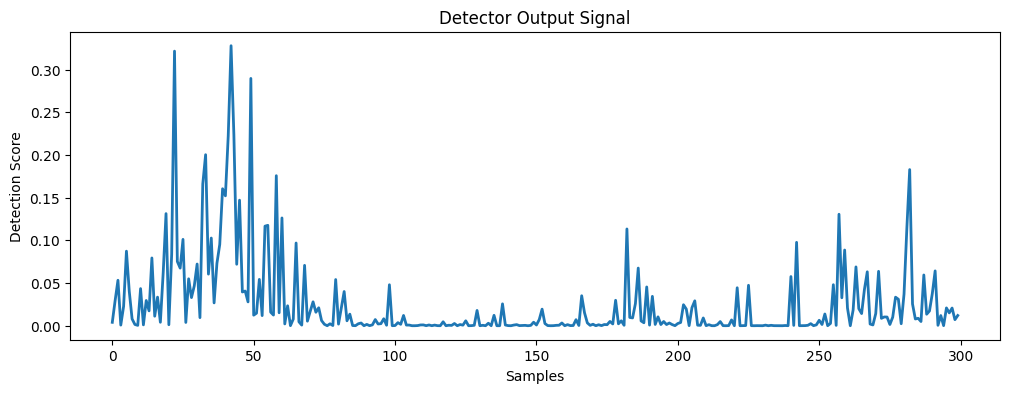

In [2]:
# Make sure model is in evaluation mode
detector_model = detector_model.to(device)  # ← IMPORTANT
detector_model.eval()

# Convert to tensor if needed
if not isinstance(padded_templates, torch.Tensor):
    x = torch.tensor(padded_templates, dtype=torch.float32)
else:
    x = padded_templates.float()

# Move to device
x = x.to(device)

# Change shape from (500, 4) → (1, 4, 500)
x = x.permute(1, 0).unsqueeze(0)

print("Input shape to model:", x.shape)
# Disable gradients for inference
with torch.no_grad():
     output = torch.sigmoid(detector_model(x))

print("Output shape:", output.shape)

output_signal = output.detach().cpu().numpy().squeeze()

plt.figure(figsize=(12, 4))
plt.plot(output_signal, linewidth=2)
plt.title("Detector Output Signal")
plt.xlabel("Samples")
plt.ylabel("Detection Score")
#plt.ylim(-0.1, 1.1)  # show spike clearly
plt.show()

In [3]:
dataFile = 'ERP_Detector_Dataset.mat'
with h5py.File(dataFile, 'r') as f:
    cell_refs = f['eeg_segments'][:]   # (26,1)

    X_list = []
    Y_list = []

    for i in range(cell_refs.shape[0]):

        struct_ref = cell_refs[i, 0]       # get reference
        struct = f[struct_ref]             # dereference

        X = f[struct['X'][()]] if isinstance(struct['X'][()], h5py.Reference) else struct['X'][()]
        Y = f[struct['Y'][()]] if isinstance(struct['Y'][()], h5py.Reference) else struct['Y'][()]
        X = np.transpose(X, (2, 1, 0)) 
        Y = np.transpose(Y, (2, 1, 0)) 
        X_list.append(np.array(X))
        Y_list.append(np.array(Y))


(4, 500)
Sum of all elements in y: 1.0
torch.Size([1, 4, 500])
Input shape to model: torch.Size([1, 4, 500])
Output shape: torch.Size([1, 1, 300])


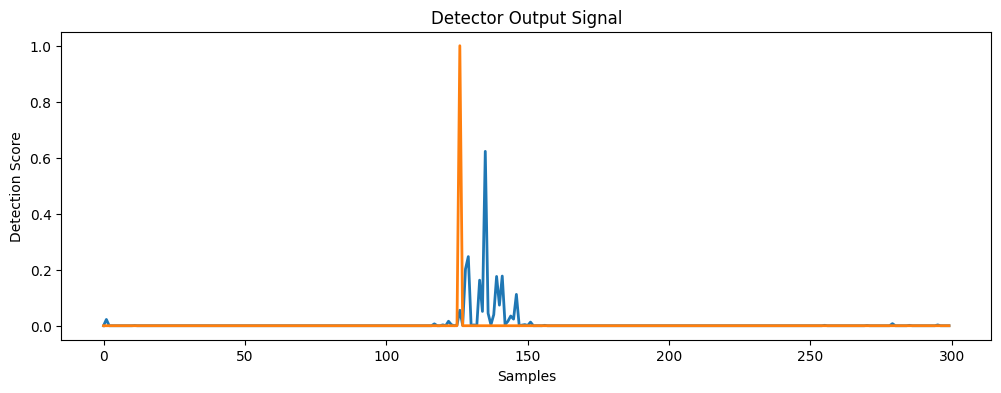

In [4]:
idx = 6
x = (X_list[0][idx,:,:])
y = (Y_list[0][idx,:,:])

# Sum all elements
total_sum = y[0].sum().item() # .item() converts from tensor to Python float
print(x.shape)
print(f"Sum of all elements in y: {total_sum}")
# Convert to tensor if needed
if not isinstance(x, torch.Tensor):
    x = torch.tensor(x, dtype=torch.float32)
else:
    x = x.float()

# Move to device
x = x.to(device)

# Change shape from (500, 4) → (1, 4, 500)
x = x.unsqueeze(0)
print(x.shape)
print("Input shape to model:", x.shape)
# Disable gradients for inference
with torch.no_grad():
    output = torch.sigmoid(detector_model(x))

print("Output shape:", output.shape)

output_signal = output.detach().cpu().numpy().squeeze()

plt.figure(figsize=(12, 4))
plt.plot(output_signal, linewidth=2)
plt.plot(y[0,:], linewidth=2)
plt.title("Detector Output Signal")
plt.xlabel("Samples")
plt.ylabel("Detection Score")
#plt.ylim(-0.1, 1.1)  # show spike clearly
plt.show()